In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

from mlxtend.evaluate.time_series import (
    GroupTimeSeriesSplit,
    plot_splits,
    print_cv_info,
    print_split_info,
)
 

# Отложенная выборка (Holdout) по времени

In [5]:
# Пример временного ряда
index = pd.date_range(start='2020-01-01', periods=100, freq='D')
data = range(100)
series = pd.Series(data, index=index)

### Метод 1 — разделить выборки по конкретной дате

In [3]:
cutoff_date = '2020-03-11'  # Дата разделения
train_data = series.loc[series.index < cutoff_date]
hold_data = series.loc[series.index >= cutoff_date]

print(f"Длина обучающей выборки (по дате): {len(train_data)}")
print(f"Длина отложенной выборки (по дате): {len(hold_data)}") 

Длина обучающей выборки (по дате): 70
Длина отложенной выборки (по дате): 30


### Метод 2 — разделить по позиции (в процентах)

In [4]:
split_point = int(len(series) * 0.8)
train_data_pos = series.iloc[:split_point]
hold_data_pos = series.iloc[split_point:]

print(f"Длина обучающей выборки (по позиции): {len(train_data_pos)}")
print(f"Длина отложенной выборки (по позиции): {len(hold_data_pos)}") 

Длина обучающей выборки (по позиции): 80
Длина отложенной выборки (по позиции): 20


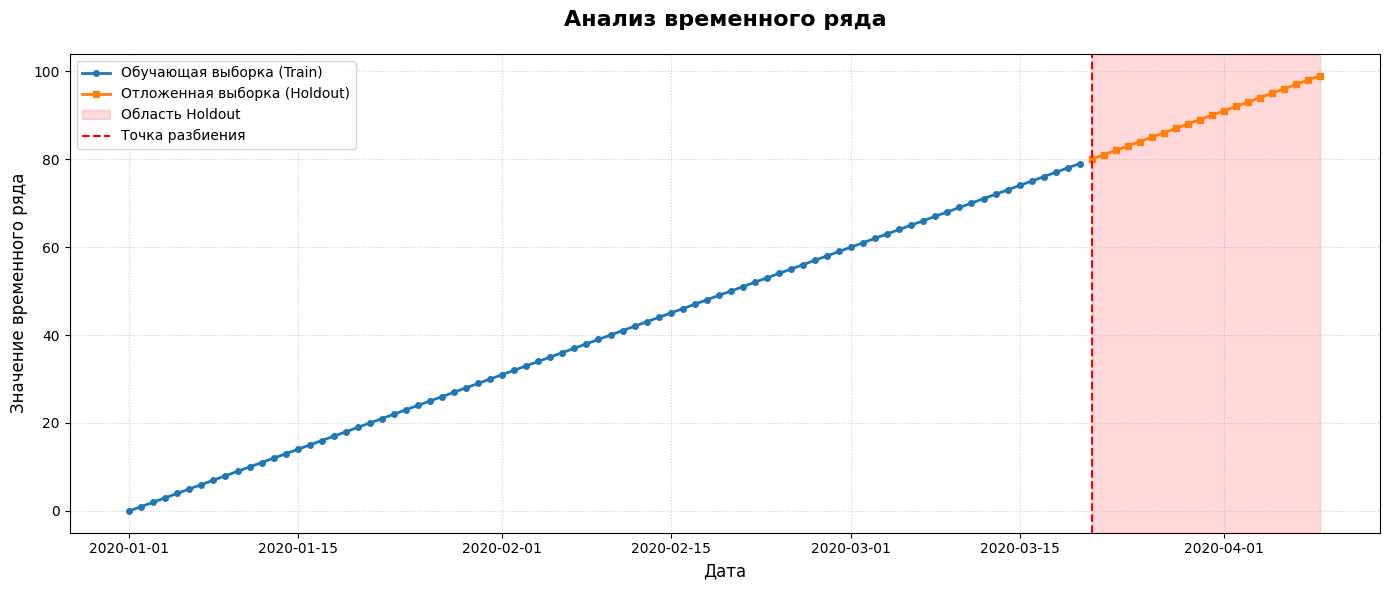

In [8]:
# Данные 
series = pd.Series(data, index=index)

# Убедимся, что данные отсортированы по дате
series = series.sort_index()

# Разделение по позиции (80% обучение / 20% отложенная)
split_point = int(len(series) * 0.8)
train_data = series.iloc[:split_point]
test_data = series.iloc[split_point:]

# --- Построение графика ---
plt.figure(figsize=(14, 6))

# Строим обучающую выборку
plt.plot(train_data, label='Обучающая выборка (Train)', color='#1f77b4', linewidth=2, marker='o', markersize=4)

# Строим отложенную выборку
plt.plot(test_data, label='Отложенная выборка (Holdout)', color='#ff7f0e', linewidth=2, marker='s', markersize=4)

# Затенение области тестовой выборки для наглядности
split_date = test_data.index[0]
plt.axvspan(split_date, test_data.index[-1], color='red', alpha=0.15, label='Область Holdout')
# Добавим пунктирную линию в месте разбиения
plt.axvline(x=split_date, color='red', linestyle='--', linewidth=1.5, label='Точка разбиения')

# Настройки графика
plt.title('Анализ временного ряда', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Значение временного ряда', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Задание 1

In [9]:
import pandas as pd

# Данные о температуре и даты (не отсортированы)
temp_data = [22, 21, 23, 20, 24, 25, 23, 22, 21, 20]
dates = pd.to_datetime([
    '2025-01-05','2025-01-01','2025-01-03','2025-01-02','2025-01-06',
    '2025-01-08','2025-01-04','2025-01-07','2025-01-09','2025-01-10'
])
series = pd.Series(temp_data, index=dates)

# Напишите ваш код здесь
# 1. Сортируйте по дате
series_sorted = series.sort_index()
# 2. Разделите на обучающую и отложенную выборки
train_data = series_sorted.iloc[:8]
test_data = series_sorted.iloc[8:]

print("Отсортированный ряд:\n", series_sorted)
print("Обучающая:\n", train_data)
print("Отложенная:\n", test_data)

Отсортированный ряд:
 2025-01-01    21
2025-01-02    20
2025-01-03    23
2025-01-04    23
2025-01-05    22
2025-01-06    24
2025-01-07    22
2025-01-08    25
2025-01-09    21
2025-01-10    20
dtype: int64
Обучающая:
 2025-01-01    21
2025-01-02    20
2025-01-03    23
2025-01-04    23
2025-01-05    22
2025-01-06    24
2025-01-07    22
2025-01-08    25
dtype: int64
Отложенная:
 2025-01-09    21
2025-01-10    20
dtype: int64


# Прогнозная скользящая валидация (TimeSeriesSplit)

In [10]:
# Создаем объект TimeSeriesSplit (например, для 5 итераций)
tscv = TimeSeriesSplit(n_splits=5)

# Проходим по фолдам и обучаем модель
for train_index, valid_index in tscv.split(X):
    # train_index всегда меньше, чем valid_index!
    X_train, X_valid = X[train_index], X[valid_index]
    y_train, y_valid = y[train_index], y[valid_index]

    # Обучаем модель на X_train, y_train
    model.fit(X_train, y_train)

    # Оцениваем модель на X_valid, y_valid
    # score = model.score(X_valid, y_valid)
    # Собираем все оценки для финального усреднения 

NameError: name 'X' is not defined

In [ ]:
# Временные данные представлены в X, y

# --- 1. Настройка TimeSeriesSplit ---
tscv = TimeSeriesSplit(n_splits=5)
print(f'Инициализирована кросс-валидация TimeSeriesSplit с n_splits={tscv.n_splits}\n')

# --- 2. Итерация по фолдам со cлучайным лесом ---
mse_scores = []
fig, axes = plt.subplots(tscv.n_splits + 1, 1, figsize=(14, 5 * (tscv.n_splits + 1)))

# Построение всего ряда для контекста
axes[0].plot(df.index, df['Value'], label='Весь временной ряд', color='gray', alpha=0.6)
axes[0].set_title('Общий вид временного ряда')
axes[0].set_ylabel('Значение')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.5)

for fold, (train_index, valid_index) in enumerate(tscv.split(X)):
    
    # 2.1. Разделение данных для текущего фолда
    X_train, X_valid = X[train_index], X[valid_index]
    y_train, y_valid = y[train_index], y[valid_index]
    train_dates = df.index[train_index]
    valid_dates = df.index[valid_index]

    # 2.2. Обучение модели: использование RandomForestRegressor
    # n_estimators=100 - количество деревьев, random_state для воспроизводимости
    model = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=100)
    model.fit(X_train, y_train)

    # 2.3. Прогнозирование
    y_pred = model.predict(X_valid)

    # 2.4. Оценка (MSE)
    mse = mean_squared_error(y_valid, y_pred)
    mse_scores.append(mse)

    print(f'Фолд {fold+1}: Размер Train = {len(X_train)}, MSE (Random Forest) = {mse:.4f}')

    # 2.5. Визуализация текущего фолда
    ax = axes[fold + 1]
    ax.plot(train_dates, y_train, label='Обучающая выборка (Train)', color='#1f77b4')
    ax.plot(valid_dates, y_valid, label='Valid выборка (Valid/Actual)', color='#ff7f0e')
    ax.plot(valid_dates, y_pred, label='Прогноз (Random Forest)', color='green', linestyle='--')
    
    ax.axvline(x=valid_dates[0], color='red', linestyle=':', alpha=0.7, label='Точка разбиения')
    ax.set_title(f'Фолд {fold+1}: Прогноз на период {valid_dates[0].date()} - {valid_dates[-1].date()} (MSE: {mse:.4f})')
    ax.set_ylabel('Значение')
    ax.legend(loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.5)

axes[-1].set_xlabel('Дата')
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

# --- 3. Визуализация ошибок MSE по фолдам ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(mse_scores)+1), mse_scores, marker='o', color='darkgreen', linewidth=2)
plt.title('Изменение ошибки MSE по фолдам (Random Forest)', fontsize=14)
plt.xlabel('Номер фолда (прогресс во времени)', fontsize=12)
plt.ylabel('Среднеквадратичная ошибка (MSE)', fontsize=12)
plt.xticks(range(1, len(mse_scores)+1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f'\nСредняя MSE Random Forest по всем фолдам: {np.mean(mse_scores):.4f}')

### Задание 2

In [13]:
X = np.arange(100)
tscv = TimeSeriesSplit(n_splits=3)

for train_index, valid_index in tscv.split(X):
    print(train_index)
    print(valid_index)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
[25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]
[50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73
 74]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74]
[75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98
 99]


# GroupTimeSeriesSplit: расширенная кросс-валидация для временных рядов

In [16]:
# Параметры разбиения:
cv_args = {
    "test_size": 1,      # размер валидационного (тестового) блока в группах
    "train_size": 3,     # количество групп для обучения
    "gap_size": 1,       # пропуск 
    "shift_size": 1,     # смещение окна между последовательными сплитами
    "window_type": "rolling"  # rolling — окно сдвигается; expanding — окно растёт
}

# Инициализация разбиения GroupTimeSeriesSplit
gtscv = GroupTimeSeriesSplit(**cv_args) 

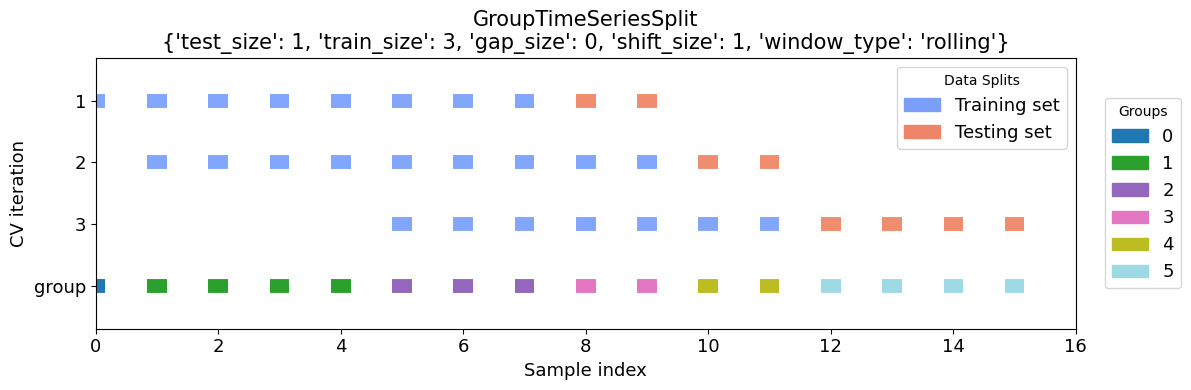

Train indices: [0 1 2 3 4 5 6 7]
Test indices: [8 9]
Train length: 8
Test length: 2
Train groups: [0 1 1 1 1 2 2 2]
Test groups: [3 3]
Train group size: 3
Test group size: 1
Train group months: <StringArray>
['2021-01', '2021-02', '2021-02', '2021-02', '2021-02', '2021-03', '2021-03',
 '2021-03']
Length: 8, dtype: str
Test group months: <StringArray>
['2021-04', '2021-04']
Length: 2, dtype: str

Train indices: [1 2 3 4 5 6 7 8 9]
Test indices: [10 11]
Train length: 9
Test length: 2
Train groups: [1 1 1 1 2 2 2 3 3]
Test groups: [4 4]
Train group size: 3
Test group size: 1
Train group months: <StringArray>
['2021-02', '2021-02', '2021-02', '2021-02', '2021-03', '2021-03', '2021-03',
 '2021-04', '2021-04']
Length: 9, dtype: str
Test group months: <StringArray>
['2021-05', '2021-05']
Length: 2, dtype: str

Train indices: [ 5  6  7  8  9 10 11]
Test indices: [12 13 14 15]
Train length: 7
Test length: 4
Train groups: [2 2 2 3 3 4 4]
Test groups: [5 5 5 5]
Train group size: 3
Test group size

In [18]:
# Пример данных
X = pd.DataFrame(np.arange(16).reshape(-1, 1), columns=["feature"])

y = pd.Series([1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0])

# Группы (например, месяцы)
groups = np.array([0, 1, 1, 1, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 5, 5])

# Для наглядности добавим индекс как «месяцы»
months_map = {i: f"2021-0{i+1}" for i in range(6)}
months = [months_map[g] for g in groups]
X.index = months

# Создаем параметры разбиения
cv_args = {"test_size": 1, "train_size": 3, "gap_size":0, "shift_size":1, "window_type": "rolling"}

# Настройка GroupTimeSeriesSplit
gtscv = GroupTimeSeriesSplit(**cv_args)

# Визуализация разбиений
plot_splits(X, y, groups=groups, **cv_args)

# Детальная информация по каждому разбиению
print_split_info(X, y, groups=groups, **cv_args)

### Задание 1

In [20]:
# Данные хранятся в X, y, группы в groups

# Создайте параметры разбиения
cv_args = {"test_size": 1, "train_size": 5, "gap_size":0, "shift_size":1, "window_type": "rolling"} # Ваш код

# Создайте разбиение по временным группам
gtscv = GroupTimeSeriesSplit(**cv_args) # Ваш код

# Выведите информацию
print_split_info(X, y, groups=groups, **cv_args)

Train indices: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Test indices: [12 13 14 15]
Train length: 12
Test length: 4
Train groups: [0 1 1 1 1 2 2 2 3 3 4 4]
Test groups: [5 5 5 5]
Train group size: 5
Test group size: 1
Train group months: <StringArray>
['2021-01', '2021-02', '2021-02', '2021-02', '2021-02', '2021-03', '2021-03',
 '2021-03', '2021-04', '2021-04', '2021-05', '2021-05']
Length: 12, dtype: str
Test group months: <StringArray>
['2021-06', '2021-06', '2021-06', '2021-06']
Length: 4, dtype: str

